<a href="https://colab.research.google.com/github/stacey017/GROUP6_REPOSITORY-/blob/main/GROUP_6___ML_LAB_ASSIGNMENT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# Install the ucimlrepo library
!pip install ucimlrepo

In [8]:
import pandas as pd
import numpy as np

In [14]:
from ucimlrepo import fetch_ucirepo, list_available_datasets

# Check available datasets
list_available_datasets()

# Example: Fetch Heart Disease dataset
heart_disease = fetch_ucirepo(id=45)

# Access features and targets
X = heart_disease.data.features
y = heart_disease.data.targets

print(X.head())
print(y.head())

print("\nDataset Information:")
print(heart_disease.metadata)

print("\nFeature Information:")
print(X.info())

print("\nMissing Values:")
print(X.isnull().sum())

print("\nTarget Distribution:")
print(y.value_counts())

# Convert target into binary classification
y_binary = (y["num"] > 0).astype(int)

# Handle missing values
X_clean = X.copy()
X_clean = X_clean.fillna(X_clean.median(numeric_only=True))

print("Missing values after cleaning:")
print(X_clean.isnull().sum())

print("\nBinary target distribution:")
print(y_binary.value_counts())

-------------------------------------
The following datasets are available:
-------------------------------------
Dataset Name                                                                            ID    
------------                                                                            --    
Abalone                                                                                 1     
Adult                                                                                   2     
Annealing                                                                               3     
Audiology (Standardized)                                                                8     
Auto MPG                                                                                9     
Automobile                                                                              10    
Balance Scale                                                                           12    
Balloons                       

## Exploratory Data Analysis (EDA)

Let's perform some Exploratory Data Analysis to understand the data distribution, relationships between variables, and identify potential patterns or anomalies. This will help us gain insights into the dataset before further modeling.

In [19]:
# 1. Display descriptive statistics for the features
print("Descriptive Statistics for Features (X_clean):")
display(X_clean.describe())

Descriptive Statistics for Features (X_clean):


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.663366,4.722772
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,1.938383
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


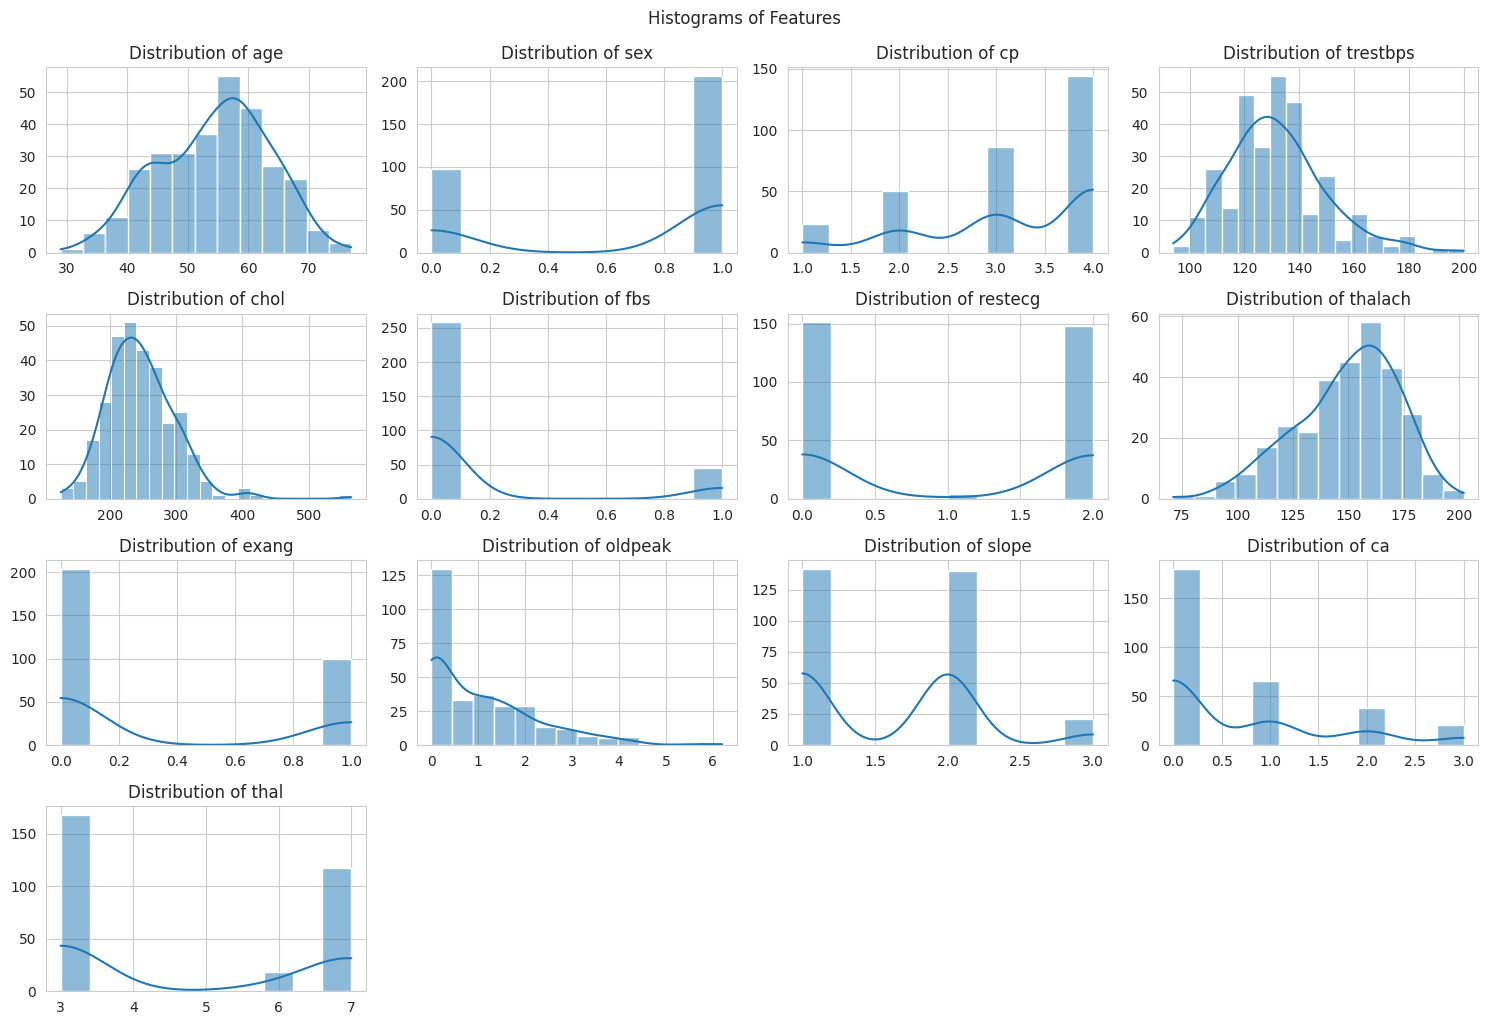

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for the plots
sns.set_style("whitegrid")

# 2. Visualize distributions of features
# We'll plot histograms for numerical features

# Identify numerical features (all features in X_clean are numerical after median imputation)
numerical_features = X_clean.columns

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(4, 4, i + 1) # Adjust subplot grid as needed
    sns.histplot(X_clean[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel('') # Remove x-axis label to avoid clutter
    plt.ylabel('') # Remove y-axis label
plt.tight_layout()
plt.suptitle('Histograms of Features', y=1.02) # Add a main title for the figure
plt.show()

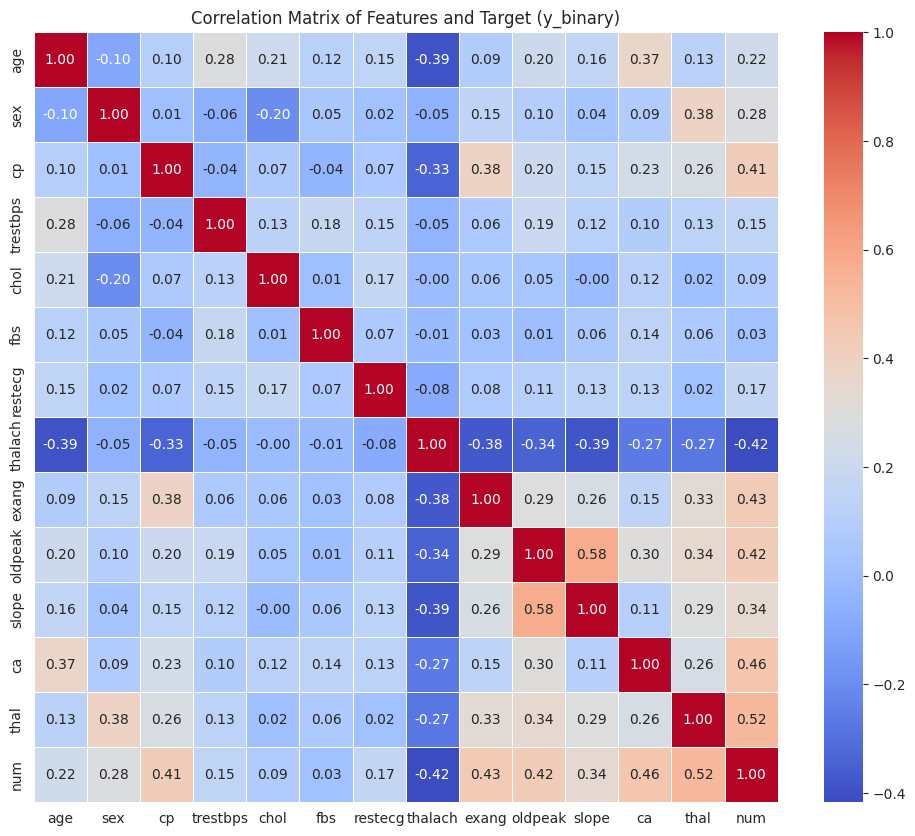

In [21]:
# 3. Analyze correlation matrix
# Combine features and the binary target for correlation calculation
df_eda = pd.concat([X_clean, y_binary], axis=1)

plt.figure(figsize=(12, 10))
sns.heatmap(df_eda.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Features and Target (y_binary)')
plt.show()

### Bivariate Analysis: Feature vs. Target (y_binary)

Let's visualize the relationship between each feature and our binary target variable (`y_binary`). This can highlight features that are more predictive of heart disease.

/tmp/ipykernel_5141/728934874.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y_binary.name, y=feature, data=df_eda, palette='viridis')
/tmp/ipykernel_5141/728934874.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y_binary.name, y=feature, data=df_eda, palette='viridis')
/tmp/ipykernel_5141/728934874.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y_binary.name, y=feature, data=df_eda, palette='viridis')
/tmp/ipykernel_5141/728934874.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be 

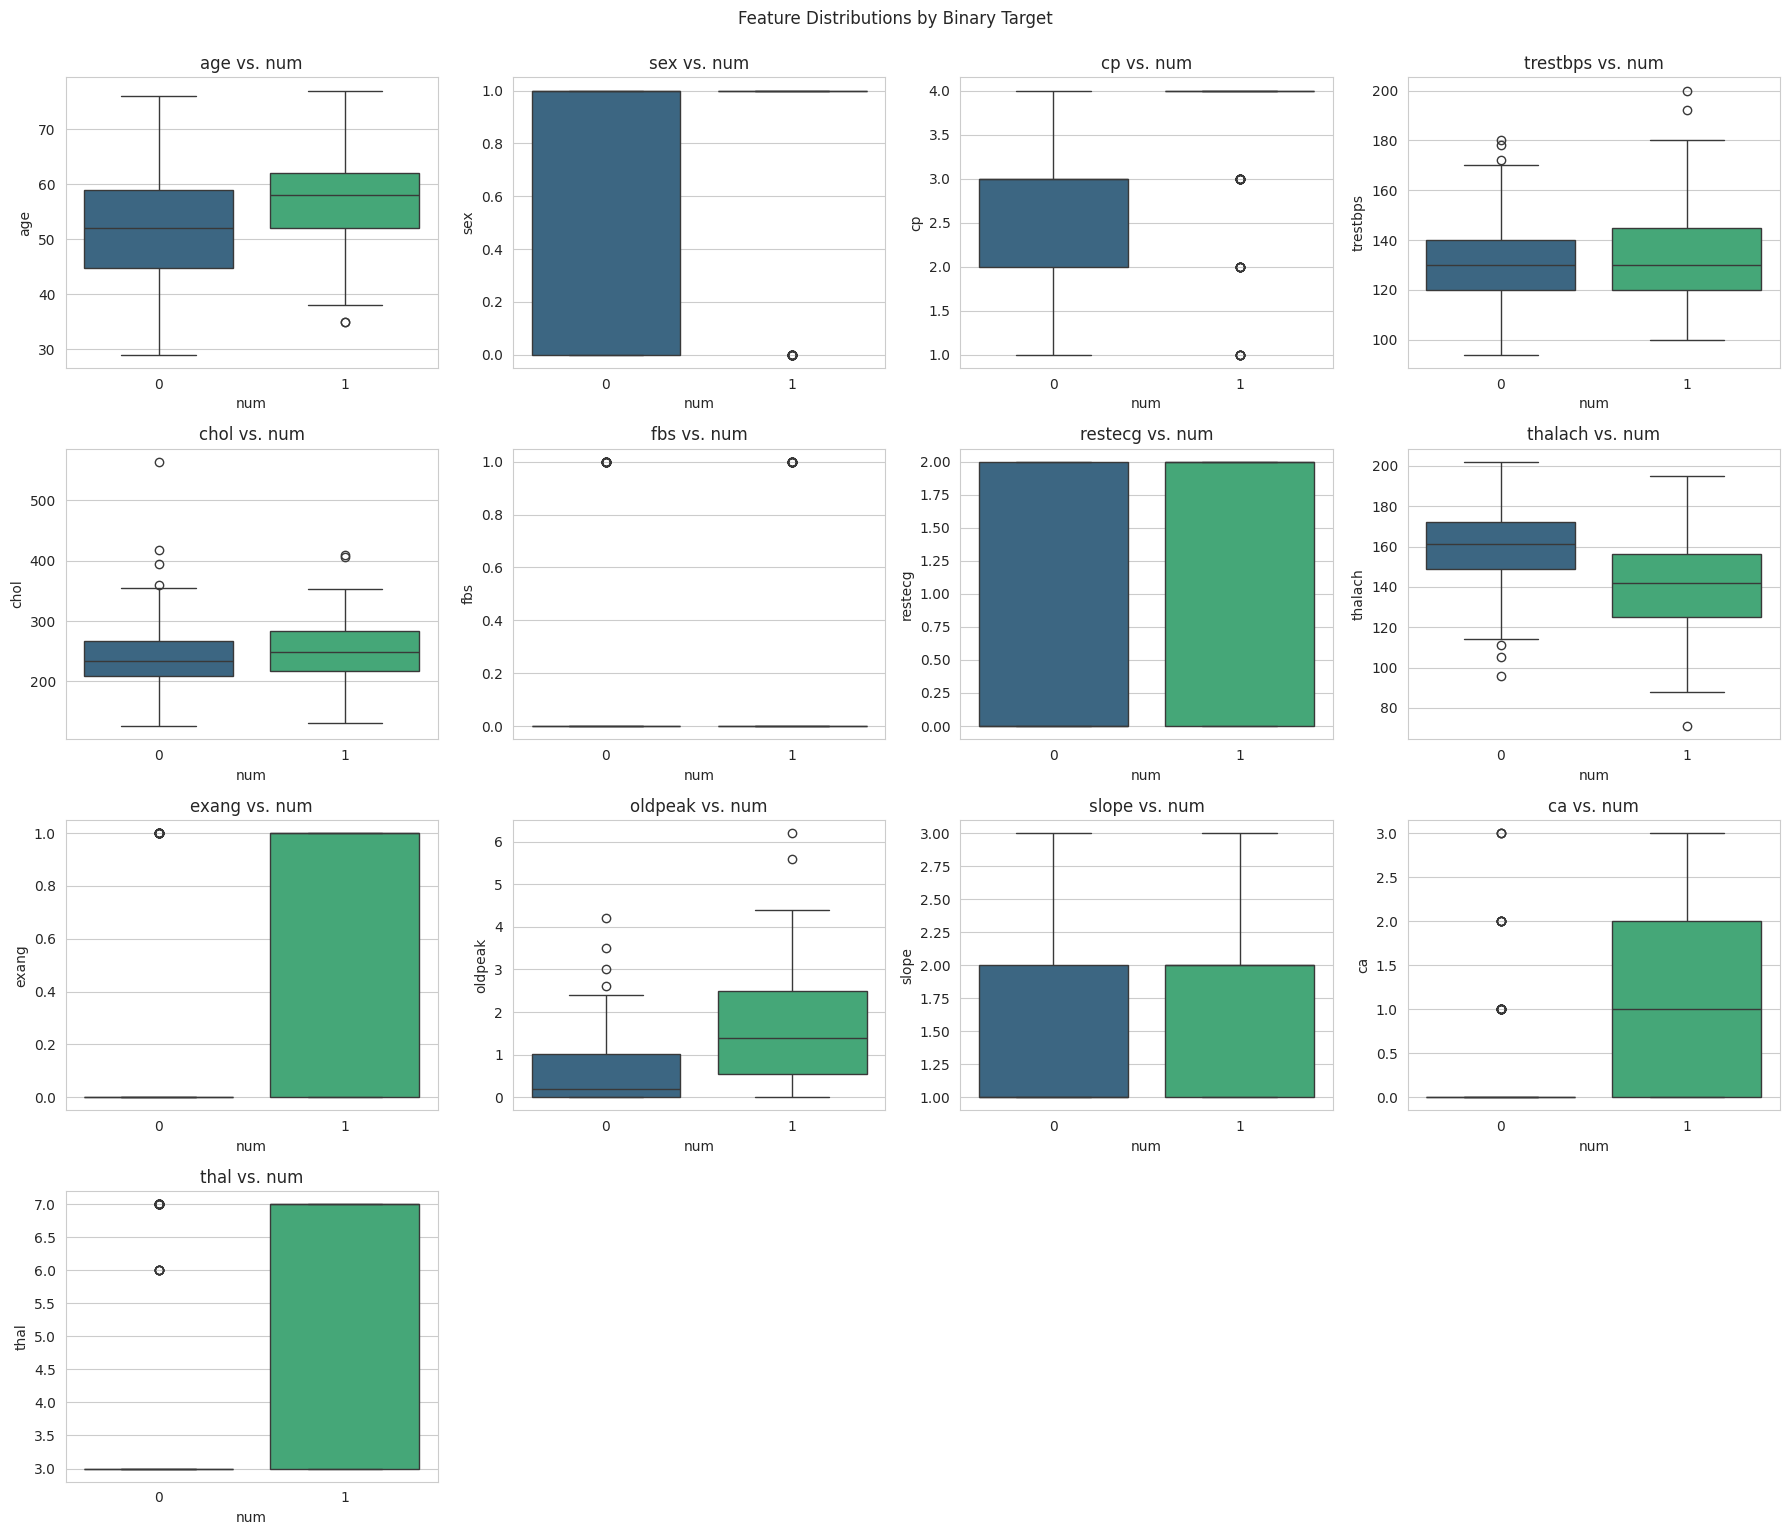

In [22]:
plt.figure(figsize=(18, 15))
for i, feature in enumerate(X_clean.columns):
    plt.subplot(4, 4, i + 1) # Adjust subplot grid as needed
    sns.boxplot(x=y_binary.name, y=feature, data=df_eda, palette='viridis')
    plt.title(f'{feature} vs. {y_binary.name}')
plt.tight_layout()
plt.suptitle('Feature Distributions by Binary Target', y=1.02) # Main title
plt.show()

## Consolidated Data Splitting, Scaling, and Model Training

To ensure all steps are executed in the correct order and prevent `NameError`s, the data splitting, feature scaling, and initial model training (Logistic Regression) are combined into this single cell.

This cell will:
1. Split the `X_clean` and `y_binary` data into training and testing sets.
2. Scale the numerical features using `StandardScaler`.
3. Train a Logistic Regression model on the scaled training data.
4. Evaluate the model's performance on the scaled test data.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- 1. Data Splitting ---
# Make sure X_clean and y_binary are defined from previous data cleaning steps
X_train, X_test, y_train, y_test = train_test_split(X_clean, y_binary, test_size=0.2, random_state=42, stratify=y_binary)

print("--- Data Splitting Complete ---")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

# --- 2. Feature Scaling ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n--- Feature Scaling Complete ---")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

# --- 3. Model Training: Logistic Regression ---
model = LogisticRegression(random_state=42, solver='liblinear')
model.fit(X_train_scaled, y_train)

print("\n--- Model Training Complete (Logistic Regression) ---")

# --- 4. Model Evaluation ---
y_pred = model.predict(X_test_scaled)

print("\n--- Model Evaluation Results ---")
print("Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

--- Data Splitting Complete ---
X_train shape: (242, 13)
X_test shape: (61, 13)

--- Feature Scaling Complete ---
X_train_scaled shape: (242, 13)
X_test_scaled shape: (61, 13)

--- Model Training Complete (Logistic Regression) ---

--- Model Evaluation Results ---
Model Accuracy: 0.8688524590163934

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61


Confusion Matrix:
 [[27  6]
 [ 2 26]]


## Data Splitting and Preprocessing

Before training a model, we need to split the data into training and testing sets. This allows us to evaluate the model's performance on unseen data. Additionally, it's often necessary to scale numerical features and one-hot encode categorical features.

In [16]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_clean, y_binary, test_size=0.2, random_state=42, stratify=y_binary)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nDistribution of binary target in training set:")
print(y_train.value_counts(normalize=True))

print("\nDistribution of binary target in testing set:")
print(y_test.value_counts(normalize=True))

X_train shape: (242, 13)
X_test shape: (61, 13)
y_train shape: (242,)
y_test shape: (61,)

Distribution of binary target in training set:
num
0    0.541322
1    0.458678
Name: proportion, dtype: float64

Distribution of binary target in testing set:
num
0    0.540984
1    0.459016
Name: proportion, dtype: float64


### Feature Scaling

Now, let's scale the numerical features using `StandardScaler`. This is important for many machine learning algorithms that are sensitive to the scale of input features.

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

Features scaled successfully.
X_train_scaled shape: (242, 13)
X_test_scaled shape: (61, 13)


### Model Training: Logistic Regression

As a first model, let's train a simple Logistic Regression classifier and evaluate its performance.

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize and train the Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is good for small datasets
model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred = model.predict(X_test_scaled)

# Evaluate the model
print("Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Model Accuracy: 0.8688524590163934

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61


Confusion Matrix:
 [[27  6]
 [ 2 26]]


## Model Training: Random Forest Classifier

Let's train a Random Forest Classifier to compare its performance with the Logistic Regression model. Random Forests are ensemble learning methods that can often provide higher accuracy.

In [23]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest model
# Using some common default parameters as a starting point
rf_model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10, min_samples_leaf=5)
rf_model.fit(X_train_scaled, y_train)

print("--- Model Training Complete (Random Forest) ---")

--- Model Training Complete (Random Forest) ---


### Random Forest Model Evaluation

Now, let's evaluate the performance of the trained Random Forest classifier.

In [24]:
# Make predictions on the scaled test set
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluate the Random Forest model
print("--- Random Forest Model Evaluation Results ---")
print("Model Accuracy (Random Forest):", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report (Random Forest):\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix (Random Forest):\n", confusion_matrix(y_test, y_pred_rf))

--- Random Forest Model Evaluation Results ---
Model Accuracy (Random Forest): 0.9016393442622951

Classification Report (Random Forest):
               precision    recall  f1-score   support

           0       0.94      0.88      0.91        33
           1       0.87      0.93      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61


Confusion Matrix (Random Forest):
 [[29  4]
 [ 2 26]]


## Model Performance Comparison

Let's compare the key performance metrics of the Logistic Regression model and the Random Forest Classifier.

In [25]:
# For comparison, retrieve Logistic Regression results (assuming they are from the last run of the previous cell)
# Accuracy for Logistic Regression was captured from the previous output: 0.8688524590163934
# Confusion Matrix for Logistic Regression:
# [[27  6]
#  [ 2 26]]

# Accuracy for Random Forest:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
confusion_rf = confusion_matrix(y_test, y_pred_rf)

print("### Accuracy Comparison:")
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, model.predict(X_test_scaled)):.4f}")
print(f"Random Forest Accuracy:     {accuracy_rf:.4f}")

print("\n### Confusion Matrix Comparison (Random Forest):\n", confusion_rf)
print("\n(Recall Logistic Regression Confusion Matrix: [[27  6] [ 2 26]])")


### Accuracy Comparison:
Logistic Regression Accuracy: 0.8689
Random Forest Accuracy:     0.9016

### Confusion Matrix Comparison (Random Forest):
 [[29  4]
 [ 2 26]]

(Recall Logistic Regression Confusion Matrix: [[27  6] [ 2 26]])


### Next Steps:

1.  **Feature Scaling**: Apply scaling (e.g., `StandardScaler`) to numerical features to ensure they contribute equally to the model.
2.  **Categorical Encoding**: Identify and one-hot encode any remaining categorical features in `X_train` and `X_test`.
3.  **Model Training**: Choose and train a classification model (e.g., Logistic Regression, Support Vector Machine, Random Forest).